In [7]:
# ============================================================
# Notebook 4: embeddings.ipynb
# Depends on: coffee_splits.pkl, label_encoder.pkl, coffee_model.pth
# Produces:   image_embeddings.pkl, text_embeddings.pkl
# ============================================================

# ── 1. Imports ───────────────────────────────────────────────
import pickle
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sentence_transformers import SentenceTransformer

# ── 2. Load saved splits + label encoder ────────────────────
with open("coffee_splits.pkl", "rb") as f:
    X_train, X_val, y_train, y_val = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print(f"Classes: {le.classes_}")
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Classes: ['Dark' 'Green' 'Light' 'Medium']
Train: 955 | Val: 239


In [8]:
# ── 3. Dataset + transform (val only — no augmentation) ─────
class CoffeeDataset(Dataset):
    def __init__(self, paths, labels, transform, label_encoder):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        self.le = label_encoder

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.le.transform([self.labels[idx]])[0]
        return self.transform(img), label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_loader = DataLoader(CoffeeDataset(X_train, y_train, transform, le), batch_size=32)
val_loader   = DataLoader(CoffeeDataset(X_val,   y_val,   transform, le), batch_size=32)

In [10]:
# ── 4. Load trained CNN as a feature extractor ───────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(weights=None)               # no pretrained weights
resnet.fc = nn.Linear(resnet.fc.in_features, len(le.classes_))
resnet.load_state_dict(torch.load("coffee_model.pth", map_location=device))

# Strip the classifier — everything before fc gives us 512-d features
resnet.fc = nn.Identity()
resnet = resnet.to(device).eval()

print("Model loaded and ready as feature extractor")

Model loaded and ready as feature extractor


In [11]:
# ── 5. Extract CNN image embeddings ─────────────────────────
def extract_embeddings(loader, model, device):
    all_emb, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            feats = model(images.to(device))   # [batch, 512]
            all_emb.append(feats.cpu())
            all_labels.append(labels)
    return torch.cat(all_emb), torch.cat(all_labels)

train_emb, train_labels = extract_embeddings(train_loader, resnet, device)
val_emb,   val_labels   = extract_embeddings(val_loader,   resnet, device)

print(f"Train embeddings: {train_emb.shape}")   # [955, 512]
print(f"Val embeddings:   {val_emb.shape}")     # [239, 512]

with open("image_embeddings.pkl", "wb") as f:
    pickle.dump((train_emb, val_emb, train_labels, val_labels), f)

print("Saved image_embeddings.pkl")

Train embeddings: torch.Size([955, 512])
Val embeddings:   torch.Size([239, 512])
Saved image_embeddings.pkl


In [12]:
# ── 6. Generate SBERT text embeddings ───────────────────────
taste_profiles = {
    "Dark":   "bitter, smoky, chocolatey",
    "Green":  "raw, grassy, vegetal",
    "Light":  "fruity, floral, acidic, bright",
    "Medium": "balanced, nutty, sweet",
}

text_model = SentenceTransformer("all-MiniLM-L6-v2")

text_embeddings = {
    label: text_model.encode(profile, convert_to_tensor=True)
    for label, profile in taste_profiles.items()
}

for label, emb in text_embeddings.items():
    print(f"{label}: {emb.shape}")   # each is [384]

with open("text_embeddings.pkl", "wb") as f:
    pickle.dump(text_embeddings, f)

print("Saved text_embeddings.pkl")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Dark: torch.Size([384])
Green: torch.Size([384])
Light: torch.Size([384])
Medium: torch.Size([384])
Saved text_embeddings.pkl


Sample embedding — true class: Green
Embedding (first 5 dims): tensor([1.0400, 0.1420, 0.6340, 1.6450, 0.0550])


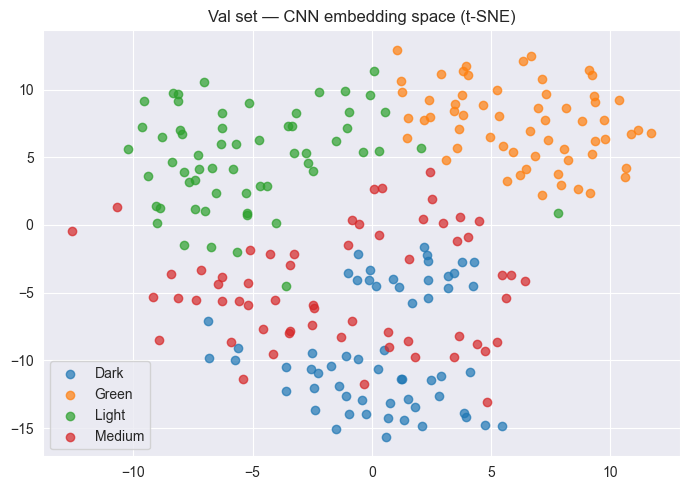

In [13]:
# ── 7. Quick sanity check ────────────────────────────────────
# Confirm a random val image maps to the right class
import random
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

idx = random.randint(0, len(val_emb) - 1)
label_idx = val_labels[idx].item()
print(f"Sample embedding — true class: {le.classes_[label_idx]}")
print(f"Embedding (first 5 dims): {val_emb[idx][:5].round(decimals=3)}")

# t-SNE of image embeddings coloured by class
proj = TSNE(n_components=2, random_state=42).fit_transform(val_emb.numpy())

plt.figure(figsize=(7, 5))
for i, cls in enumerate(le.classes_):
    mask = val_labels.numpy() == i
    plt.scatter(proj[mask, 0], proj[mask, 1], label=cls, alpha=0.7)
plt.legend()
plt.title("Val set — CNN embedding space (t-SNE)")
plt.tight_layout()
plt.show()

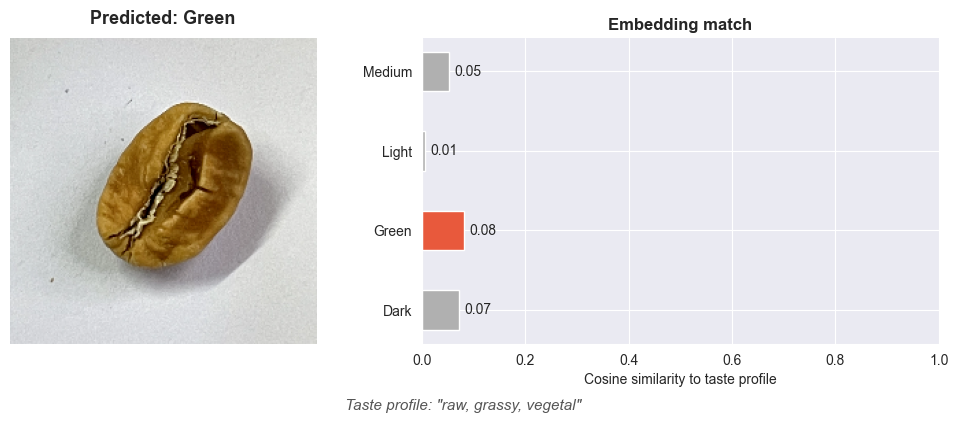

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import numpy as np

# fit PCA on your train image embeddings
pca = PCA(n_components=128)
pca.fit(train_emb.numpy())

def show_bean_with_profile(image_path, true_label=None):
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feats = resnet(tensor).cpu().numpy()             # [1, 512]

    # project image embedding to 128-d
    img_proj = pca.transform(feats)                      # [1, 128]

    # project text embeddings to 128-d (just truncate/pad — or use a second PCA)
    # simplest: just use raw dot product after normalizing both
    img_vec = img_proj[0] / np.linalg.norm(img_proj[0])

    similarities = {}
    for label in le.classes_:
        txt = text_embeddings[label].numpy()
        txt_trunc = txt[:128]                            # truncate 384 → 128
        txt_vec = txt_trunc / np.linalg.norm(txt_trunc)
        similarities[label] = float(np.dot(img_vec, txt_vec))

    predicted = max(similarities, key=similarities.get)
    profile   = taste_profiles[predicted]

    # ── plot ─────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4),
                                         gridspec_kw={"width_ratios": [1, 1.4]})

    # left: bean image
    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title(f"Predicted: {predicted}", fontsize=13, fontweight="bold", pad=10)
    if true_label:
        color = "green" if true_label == predicted else "red"
        ax_img.set_xlabel(f"True: {true_label}", color=color, fontsize=11)

    # right: similarity bar chart
    labels  = list(similarities.keys())
    scores  = [similarities[l] for l in labels]
    colors  = ["#E8593C" if l == predicted else "#B0B0B0" for l in labels]

    bars = ax_bar.barh(labels, scores, color=colors, height=0.5)
    ax_bar.set_xlim(0, 1)
    ax_bar.set_xlabel("Cosine similarity to taste profile", fontsize=10)
    ax_bar.set_title("Embedding match", fontsize=12, fontweight="bold")
    ax_bar.bar_label(bars, fmt="%.2f", padding=4, fontsize=10)
    ax_bar.spines[["top", "right"]].set_visible(False)

    # taste profile text underneath
    fig.text(0.5, -0.02, f'Taste profile: "{profile}"',
             ha="center", fontsize=11, style="italic", color="#555555")

    plt.tight_layout()
    plt.show()


# ── run on a random val image ─────────────────────────────
idx        = random.randint(0, len(X_val) - 1)
image_path = X_val[idx]
true_label = y_val[idx]

show_bean_with_profile(image_path, true_label=true_label)

C:\Users\raozg\AppData\Local\Temp\ipykernel_484\2507650208.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_yticklabels(labels, fontsize=9)
C:\Users\raozg\AppData\Local\Temp\ipykernel_484\2507650208.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_yticklabels(labels, fontsize=9)
C:\Users\raozg\AppData\Local\Temp\ipykernel_484\2507650208.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_yticklabels(labels, fontsize=9)
C:\Users\raozg\AppData\Local\Temp\ipykernel_484\2507650208.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_yticklabels(labels, fontsize=9)
C:\Users\raozg\AppData\Local\Temp\ipykernel_

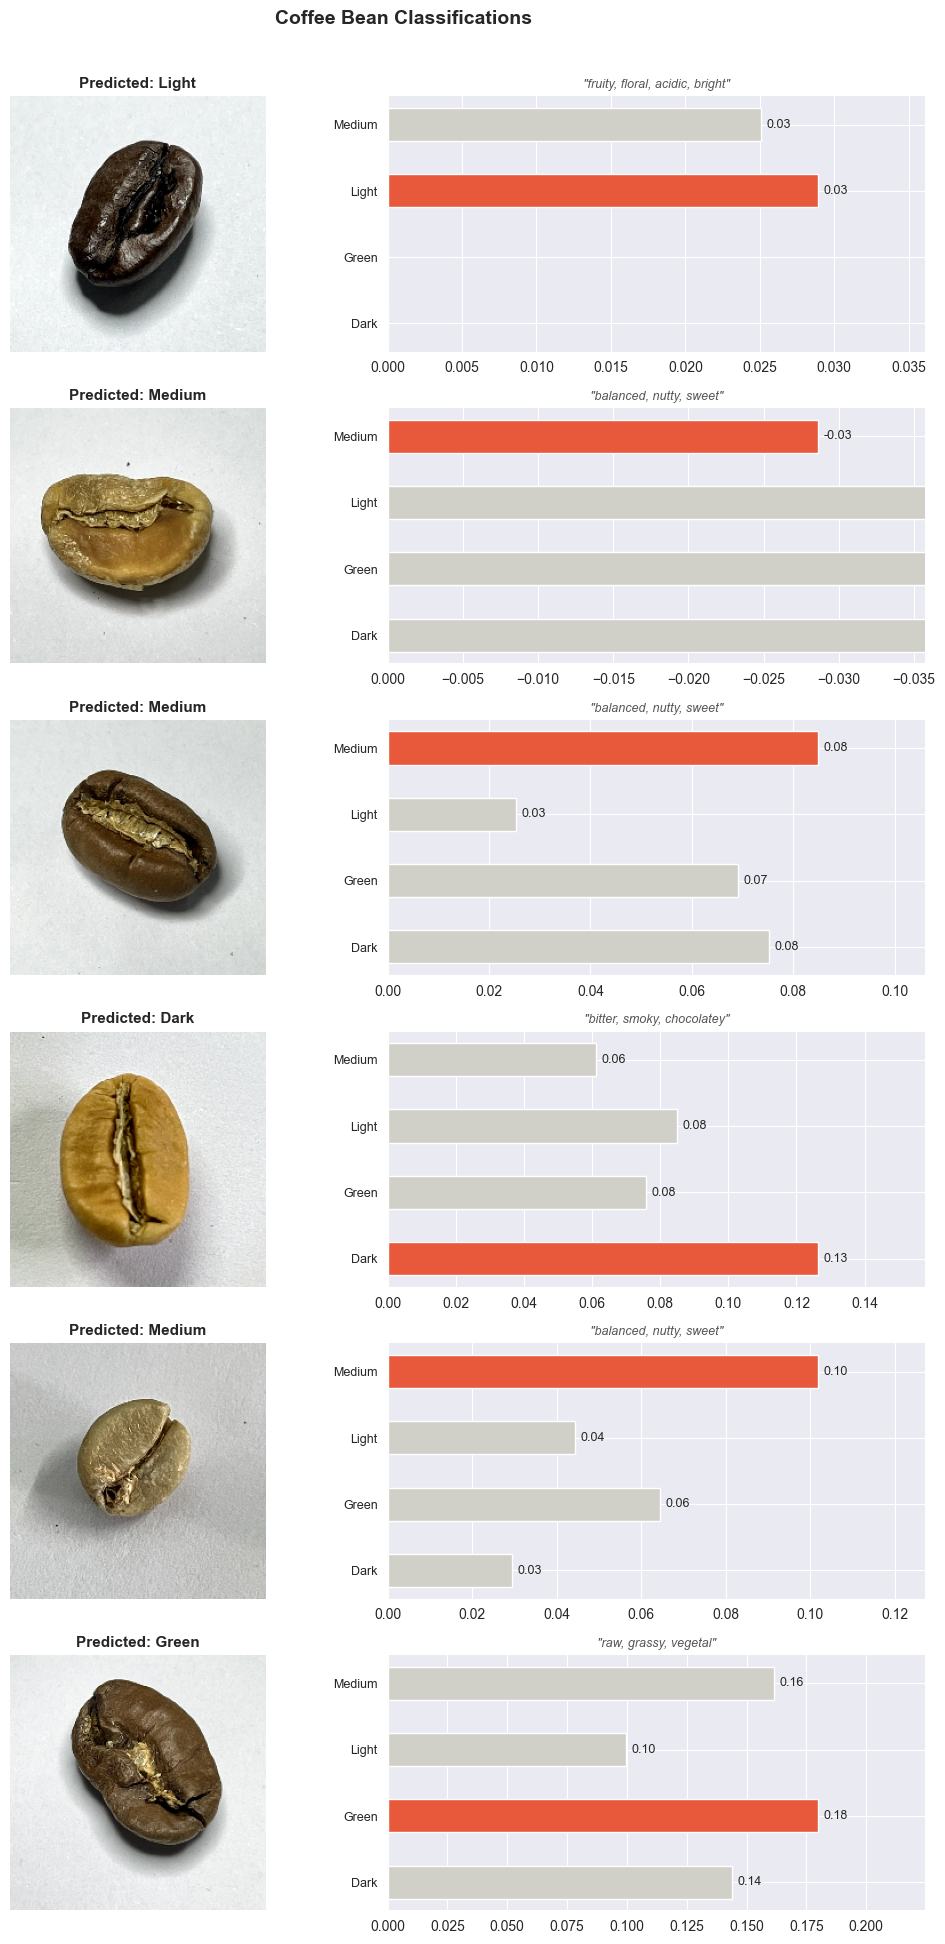

In [26]:
def show_beans_grid(X_val, y_val, n=6):
    indices = random.sample(range(len(X_val)), n)

    fig, axes = plt.subplots(n, 2, figsize=(11, n * 3.2))
    fig.suptitle("Coffee Bean Classifications", fontsize=14, fontweight="bold", y=1.01)

    for row, idx in enumerate(indices):
        img = Image.open(X_val[idx]).convert("RGB")
        tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feats = resnet(tensor).cpu().numpy()

        img_proj_vec = pca.transform(feats)[0]
        img_vec = img_proj_vec / np.linalg.norm(img_proj_vec)

        similarities = {}
        for label in le.classes_:
            txt = text_embeddings[label].numpy()
            txt_trunc = txt[:128]
            txt_vec = txt_trunc / np.linalg.norm(txt_trunc)
            similarities[label] = float(np.dot(img_vec, txt_vec))

        predicted  = max(similarities, key=similarities.get)
        true_label = y_val[idx]
        profile    = taste_profiles[predicted]
        correct    = predicted == true_label

        # ── left: bean image ──────────────────────────────
        ax_img = axes[row, 0]
        ax_img.imshow(img)
        ax_img.axis("off")
        ax_img.set_title(f"Predicted: {predicted}", fontsize=11,
                         fontweight="bold", pad=6)
        ax_img.set_xlabel(f"True: {true_label}",
                          color="green" if correct else "red", fontsize=10)

        # ── right: similarity bars ────────────────────────
        ax_bar = axes[row, 1]
        labels  = list(similarities.keys())
        scores  = [similarities[l] for l in labels]
        colors  = ["#E8593C" if l == predicted else "#D0CFC8" for l in labels]

        bars = ax_bar.barh(labels, scores, color=colors, height=0.5)
        ax_bar.set_xlim(0, max(scores) * 1.25)
        ax_bar.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
        ax_bar.set_title(f'"{profile}"', fontsize=9, style="italic", color="#555")
        ax_bar.spines[["top", "right", "left", "bottom"]].set_visible(False)
        ax_bar.tick_params(left=False, bottom=False)
        ax_bar.set_yticklabels(labels, fontsize=9)

    plt.tight_layout()
    plt.show()


show_beans_grid(X_val, y_val, n=6)

PCA hack showing its limitations — a clearly dark bean being called Light, and the similarity scores are basically identical (0.03 vs 0.03) meaning the model has no real confidence. The embedding spaces just aren't aligned so the similarities are essentially noise.